In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pickle
import plotly.graph_objs as go
import plotly.express as px
import numpy as np
from scipy.spatial import KDTree
import torch.nn.functional as F

In [3]:
with open('../debug.pickle', 'rb') as f:
    data = pickle.load(f)

src_shape_feats = F.normalize(data['src_shape_feats'].unsqueeze(0), p=2, dim=1).squeeze(0).T.cpu().detach().numpy()
trg_shape_feats = F.normalize(data['trg_shape_feats'].unsqueeze(0), p=2, dim=1).squeeze(0).T.cpu().detach().numpy()

# src_shape_feats = data['src_shape_feats'].T.cpu().detach().numpy()
# trg_shape_feats = data['trg_shape_feats'].T.cpu().detach().numpy()

src_occ_feats = data['src_occ_feats'].T.cpu().detach().numpy()
trg_occ_feats = data['trg_occ_feats'].T.cpu().detach().numpy()
src_matching_feats = data['src_matching_feats'].T.cpu().detach().numpy()
trg_matching_feats = data['trg_matching_feats'].T.cpu().detach().numpy()
src_ori = data['src_ori'].cpu().detach().numpy()
trg_ori = data['trg_ori'].cpu().detach().numpy()
gt_correspondence = data['gt_correspondence'].cpu().detach().numpy()
src_pcd_raw = data['src_pcd_raw'].cpu().detach().numpy()
trg_pcd_raw = data['trg_pcd_raw'].cpu().detach().numpy()
src_pcd = data['src_pcd'].cpu().detach().numpy()
trg_pcd = data['trg_pcd'].cpu().detach().numpy()
src_gt_rot = data['src_gt_rot'].cpu().detach().numpy()
trg_gt_rot = data['trg_gt_rot'].cpu().detach().numpy()
estimated_rotat = data['estimated_rotat'].cpu().detach().numpy()
estimated_trans = data['estimated_trans'].cpu().detach().numpy()
pred_corr = data['pred_corr'].cpu().detach().numpy()

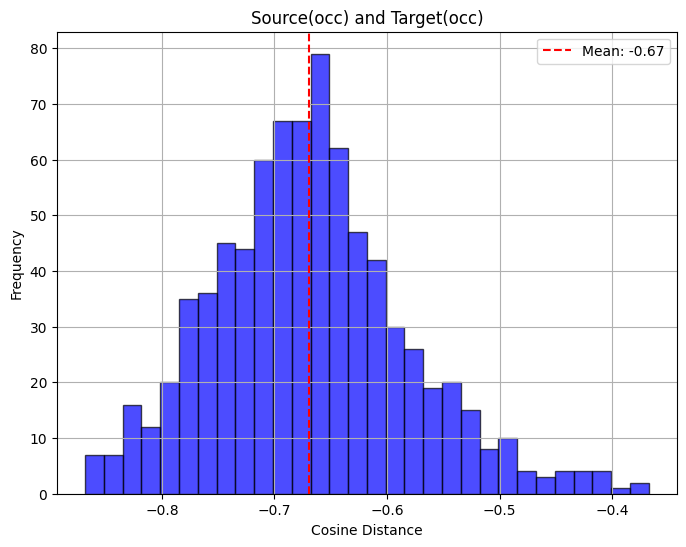

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cosine distance map
cosine_dist_map = src_occ_feats[gt_correspondence[:, 0]] @ trg_occ_feats[gt_correspondence[:, 1]].T

# Extract the diagonal elements
diagonal_elements = np.diag(cosine_dist_map)

# Calculate the mean of the diagonal elements
mean_diagonal = np.mean(diagonal_elements)

# Plot the histogram of the diagonal elements
plt.figure(figsize=(8, 6))
plt.hist(diagonal_elements, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(mean_diagonal, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_diagonal:.2f}')
plt.title('Source(occ) and Target(occ)')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

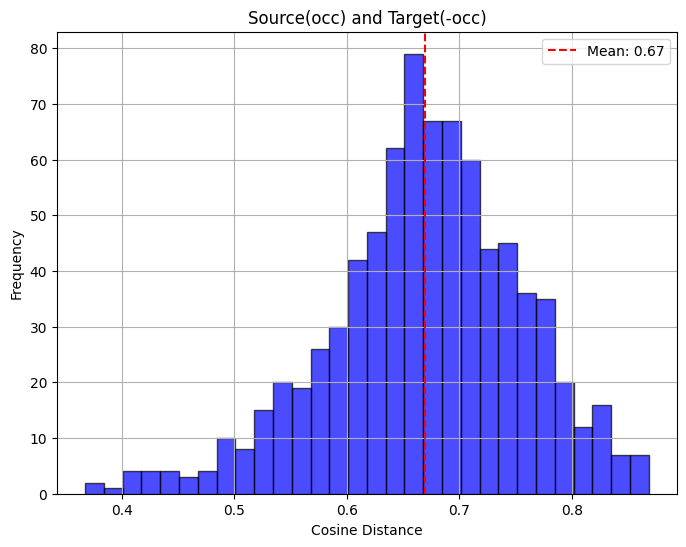

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cosine distance map
cosine_dist_map = src_occ_feats[gt_correspondence[:, 0]] @ -trg_occ_feats[gt_correspondence[:, 1]].T

# Extract the diagonal elements
diagonal_elements = np.diag(cosine_dist_map)

# Calculate the mean of the diagonal elements
mean_diagonal = np.mean(diagonal_elements)

# Plot the histogram of the diagonal elements
plt.figure(figsize=(8, 6))
plt.hist(diagonal_elements, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(mean_diagonal, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_diagonal:.2f}')
plt.title('Source(occ) and Target(-occ)')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

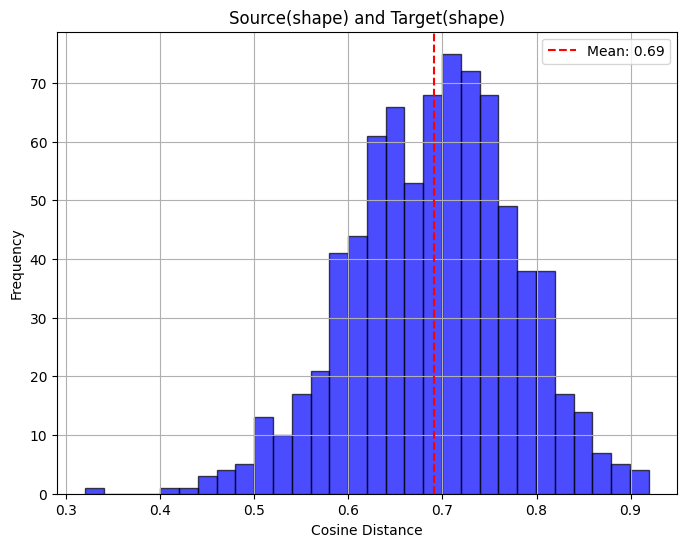

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate cosine distance map
cosine_dist_map = src_shape_feats[gt_correspondence[:, 0]] @ trg_shape_feats[gt_correspondence[:, 1]].T

# Extract the diagonal elements
diagonal_elements = np.diag(cosine_dist_map)

# Calculate the mean of the diagonal elements
mean_diagonal = np.mean(diagonal_elements)

# Plot the histogram of the diagonal elements
plt.figure(figsize=(8, 6))
plt.hist(diagonal_elements, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(mean_diagonal, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_diagonal:.2f}')
plt.title('Source(shape) and Target(shape)')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

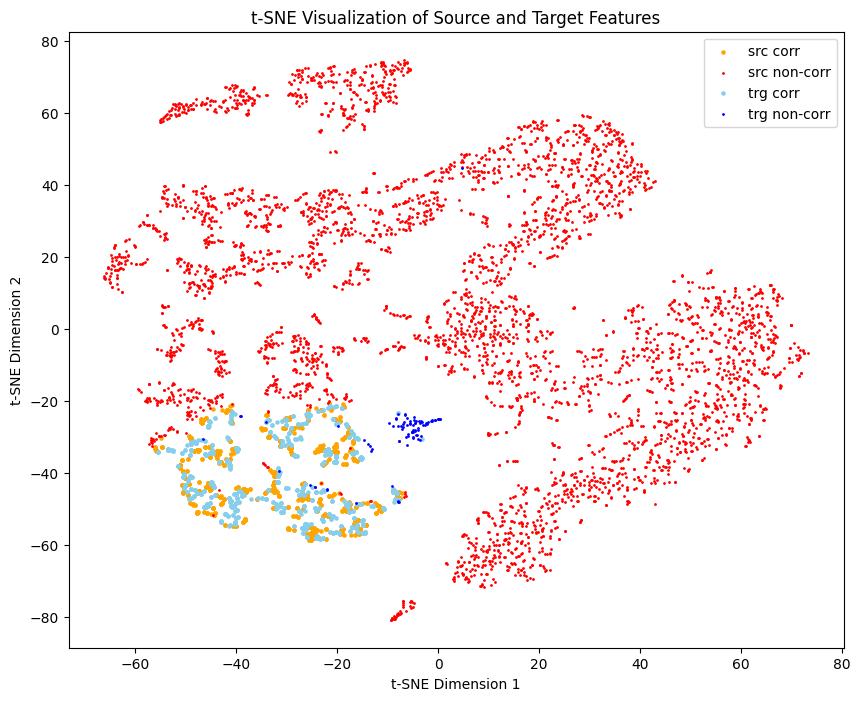

In [47]:
all_feats = np.concatenate((src_shape_feats, trg_shape_feats), axis=0)  # 모든 특징을 하나의 행렬로 결합
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(all_feats)

# 데이터 분리: src와 trg의 시작 및 끝 인덱스 정의
src_end = len(src_shape_feats)
trg_start = src_end
trg_end = trg_start + len(trg_shape_feats)

# Correspondence 인덱스 정의
corr_src_indices = gt_correspondence[:, 0]
corr_trg_indices = gt_correspondence[:, 1] + trg_start  # trg의 인덱스를 전체 배열의 인덱스로 변환

# Non-correspondence 인덱스
non_corr_src_indices = np.setdiff1d(np.arange(src_end), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(trg_start, trg_end), corr_trg_indices)

# 색상 배열 생성
colors = np.array(['red'] * src_end + ['blue'] * len(trg_shape_feats), dtype='object')
colors[corr_src_indices] = 'orange'
colors[corr_trg_indices] = 'skyblue'

# 그래프 그리기
plt.figure(figsize=(10, 8))
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_src_indices, 0], features_2d[non_corr_src_indices, 1], c='red', s=1, label='src non-corr')
plt.scatter(features_2d[corr_trg_indices, 0], features_2d[corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[non_corr_trg_indices, 0], features_2d[non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')

# 레이블과 타이틀 설정
plt.legend()
plt.title('t-SNE Visualization of Source and Target Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

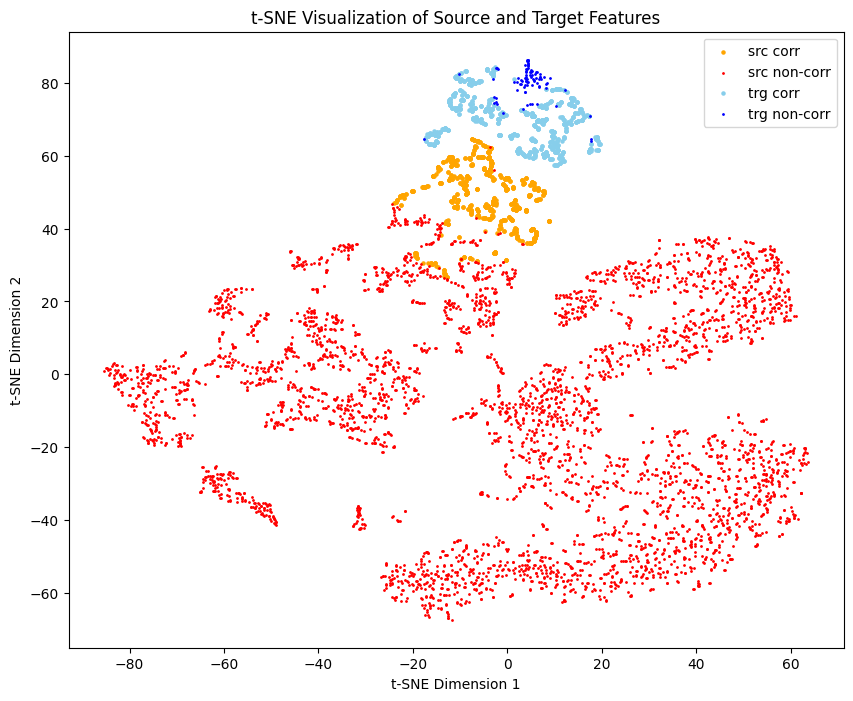

In [48]:
all_feats = np.concatenate((src_shape_feats, -trg_shape_feats), axis=0)  # 모든 특징을 하나의 행렬로 결합
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(all_feats)

# 데이터 분리: src와 trg의 시작 및 끝 인덱스 정의
src_end = len(src_shape_feats)
trg_start = src_end
trg_end = trg_start + len(trg_shape_feats)

# Correspondence 인덱스 정의
corr_src_indices = gt_correspondence[:, 0]
corr_trg_indices = gt_correspondence[:, 1] + trg_start  # trg의 인덱스를 전체 배열의 인덱스로 변환

# Non-correspondence 인덱스
non_corr_src_indices = np.setdiff1d(np.arange(src_end), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(trg_start, trg_end), corr_trg_indices)

# 색상 배열 생성
colors = np.array(['red'] * src_end + ['blue'] * len(trg_shape_feats), dtype='object')
colors[corr_src_indices] = 'orange'
colors[corr_trg_indices] = 'skyblue'

# 그래프 그리기
plt.figure(figsize=(10, 8))
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_src_indices, 0], features_2d[non_corr_src_indices, 1], c='red', s=1, label='src non-corr')
plt.scatter(features_2d[corr_trg_indices, 0], features_2d[corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[non_corr_trg_indices, 0], features_2d[non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')

# 레이블과 타이틀 설정
plt.legend()
plt.title('t-SNE Visualization of Source and Target Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

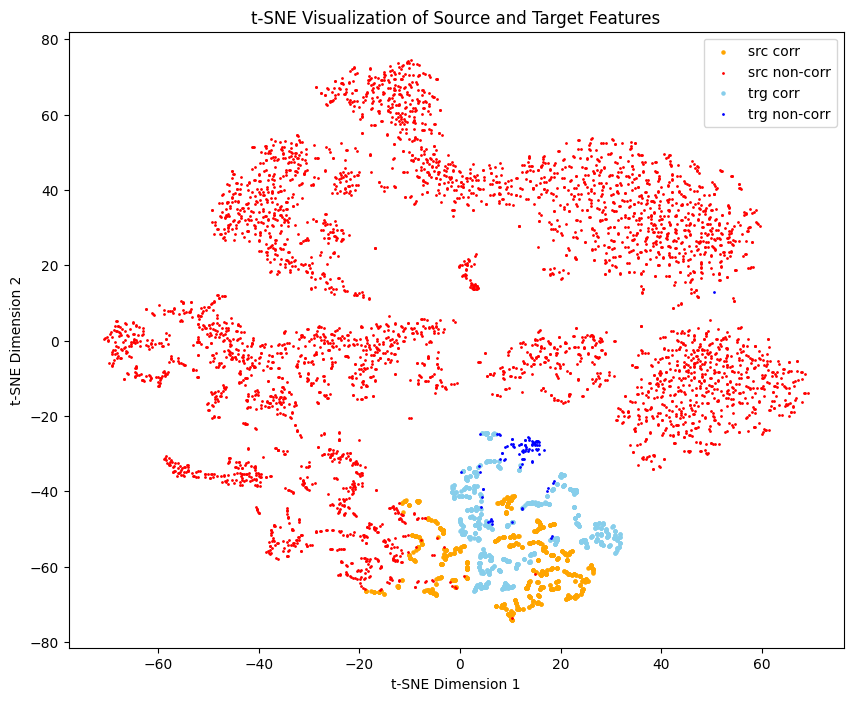

In [49]:
all_feats = np.concatenate((src_occ_feats, trg_occ_feats), axis=0)  # 모든 특징을 하나의 행렬로 결합
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(all_feats)

# 데이터 분리: src와 trg의 시작 및 끝 인덱스 정의
src_end = len(src_occ_feats)
trg_start = src_end
trg_end = trg_start + len(trg_occ_feats)

# Correspondence 인덱스 정의
corr_src_indices = gt_correspondence[:, 0]
corr_trg_indices = gt_correspondence[:, 1] + trg_start  # trg의 인덱스를 전체 배열의 인덱스로 변환

# Non-correspondence 인덱스
non_corr_src_indices = np.setdiff1d(np.arange(src_end), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(trg_start, trg_end), corr_trg_indices)

# 색상 배열 생성
colors = np.array(['red'] * src_end + ['blue'] * len(trg_occ_feats), dtype='object')
colors[corr_src_indices] = 'orange'
colors[corr_trg_indices] = 'skyblue'

# 그래프 그리기
plt.figure(figsize=(10, 8))
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_src_indices, 0], features_2d[non_corr_src_indices, 1], c='red', s=1, label='src non-corr')
plt.scatter(features_2d[corr_trg_indices, 0], features_2d[corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[non_corr_trg_indices, 0], features_2d[non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')

# 레이블과 타이틀 설정
plt.legend()
plt.title('t-SNE Visualization of Source and Target Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

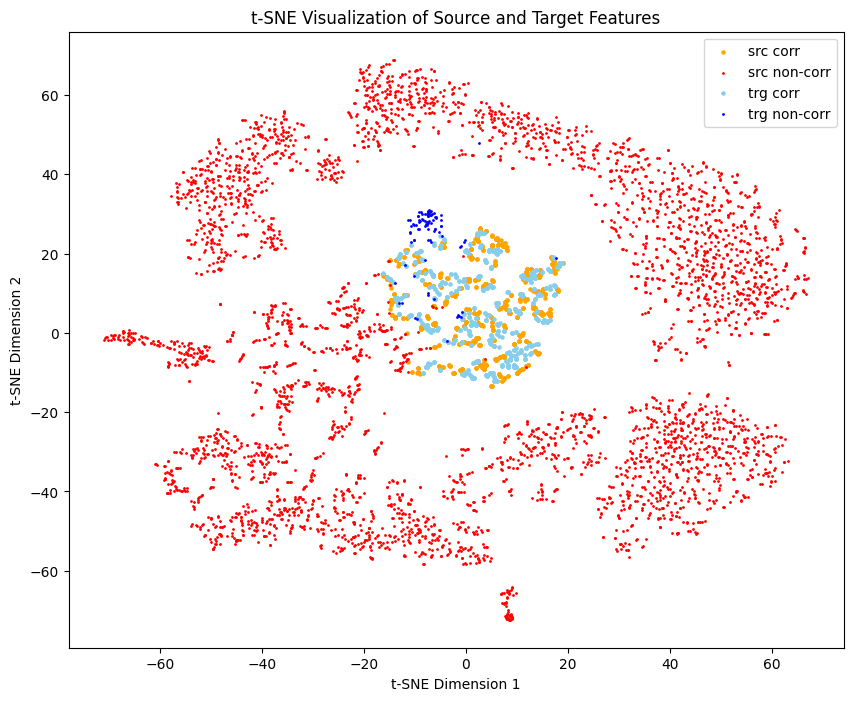

In [50]:
all_feats = np.concatenate((src_occ_feats, -trg_occ_feats), axis=0)  # 모든 특징을 하나의 행렬로 결합
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(all_feats)

# 데이터 분리: src와 trg의 시작 및 끝 인덱스 정의
src_end = len(src_occ_feats)
trg_start = src_end
trg_end = trg_start + len(-trg_occ_feats)

# Correspondence 인덱스 정의
corr_src_indices = gt_correspondence[:, 0]
corr_trg_indices = gt_correspondence[:, 1] + trg_start  # trg의 인덱스를 전체 배열의 인덱스로 변환

# Non-correspondence 인덱스
non_corr_src_indices = np.setdiff1d(np.arange(src_end), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(trg_start, trg_end), corr_trg_indices)

# 색상 배열 생성
colors = np.array(['red'] * src_end + ['blue'] * len(-trg_occ_feats), dtype='object')
colors[corr_src_indices] = 'orange'
colors[corr_trg_indices] = 'skyblue'

# 그래프 그리기
plt.figure(figsize=(10, 8))
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_src_indices, 0], features_2d[non_corr_src_indices, 1], c='red', s=1, label='src non-corr')
plt.scatter(features_2d[corr_trg_indices, 0], features_2d[corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[non_corr_trg_indices, 0], features_2d[non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')

# 레이블과 타이틀 설정
plt.legend()
plt.title('t-SNE Visualization of Source and Target Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

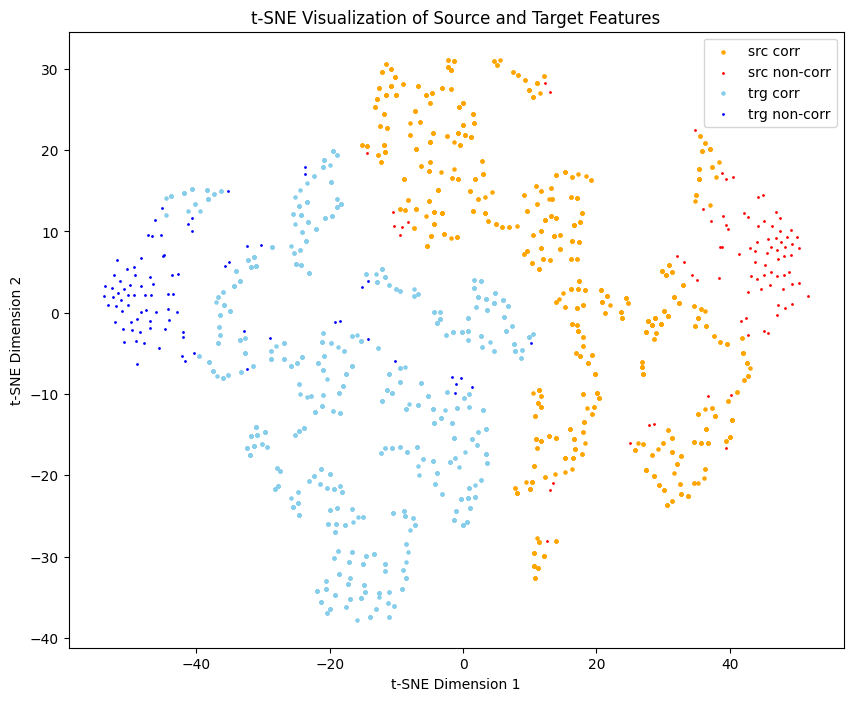

In [51]:
all_feats = np.concatenate((trg_occ_feats, -trg_occ_feats), axis=0)  # 모든 특징을 하나의 행렬로 결합
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(all_feats)

# 데이터 분리: src와 trg의 시작 및 끝 인덱스 정의
src_end = len(trg_occ_feats)
trg_start = src_end
trg_end = trg_start + len(trg_occ_feats)

# Correspondence 인덱스 정의
corr_src_indices = gt_correspondence[:, 1]
corr_trg_indices = gt_correspondence[:, 1] + trg_start  # trg의 인덱스를 전체 배열의 인덱스로 변환

# Non-correspondence 인덱스
non_corr_src_indices = np.setdiff1d(np.arange(src_end), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(trg_start, trg_end), corr_trg_indices)

# 색상 배열 생성
colors = np.array(['red'] * src_end + ['blue'] * len(trg_occ_feats), dtype='object')
colors[corr_src_indices] = 'orange'
colors[corr_trg_indices] = 'skyblue'

# 그래프 그리기
plt.figure(figsize=(10, 8))
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_src_indices, 0], features_2d[non_corr_src_indices, 1], c='red', s=1, label='src non-corr')
plt.scatter(features_2d[corr_trg_indices, 0], features_2d[corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[non_corr_trg_indices, 0], features_2d[non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')

# 레이블과 타이틀 설정
plt.legend()
plt.title('t-SNE Visualization of Source and Target Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

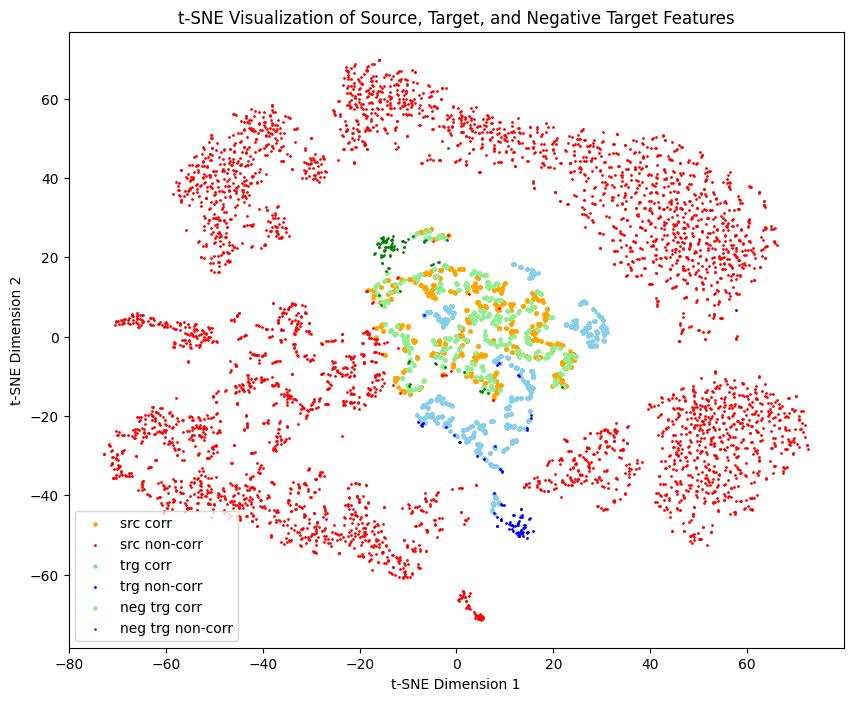

In [52]:
# 모든 특징을 하나의 행렬로 결합: src, trg, -trg
all_feats = np.concatenate((src_occ_feats, trg_occ_feats, -trg_occ_feats), axis=0)

# t-SNE 수행
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(all_feats)

# 데이터 분리: src, trg, -trg의 시작 및 끝 인덱스 정의
src_end = len(src_occ_feats)
trg_start = src_end
trg_end = trg_start + len(trg_occ_feats)
neg_trg_start = trg_end
neg_trg_end = neg_trg_start + len(-trg_occ_feats)

# Correspondence 인덱스 정의
corr_src_indices = gt_correspondence[:, 0]
corr_trg_indices = gt_correspondence[:, 1] + trg_start  # trg의 인덱스를 전체 배열의 인덱스로 변환
corr_neg_trg_indices = gt_correspondence[:, 1] + neg_trg_start  # -trg의 인덱스를 변환

# Non-correspondence 인덱스
non_corr_src_indices = np.setdiff1d(np.arange(src_end), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(trg_start, trg_end), corr_trg_indices)
non_corr_neg_trg_indices = np.setdiff1d(np.arange(neg_trg_start, neg_trg_end), corr_neg_trg_indices)

# 색상 배열 생성
colors = np.array(['red'] * src_end + ['green'] * len(trg_occ_feats) + ['blue'] * len(-trg_occ_feats), dtype='object')
colors[corr_src_indices] = 'orange'
colors[corr_trg_indices] = 'skyblue'
colors[corr_neg_trg_indices] = 'lightgreen'

# 그래프 그리기
plt.figure(figsize=(10, 8))

# Source
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_src_indices, 0], features_2d[non_corr_src_indices, 1], c='red', s=1, label='src non-corr')

# Target
plt.scatter(features_2d[corr_trg_indices, 0], features_2d[corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[non_corr_trg_indices, 0], features_2d[non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')

# Negative Target (-trg)
plt.scatter(features_2d[corr_neg_trg_indices, 0], features_2d[corr_neg_trg_indices, 1], c='lightgreen', s=5, label='neg trg corr')
plt.scatter(features_2d[non_corr_neg_trg_indices, 0], features_2d[non_corr_neg_trg_indices, 1], c='green', s=1, label='neg trg non-corr')

# 레이블과 타이틀 설정
plt.legend()
plt.title('t-SNE Visualization of Source, Target, and Negative Target Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

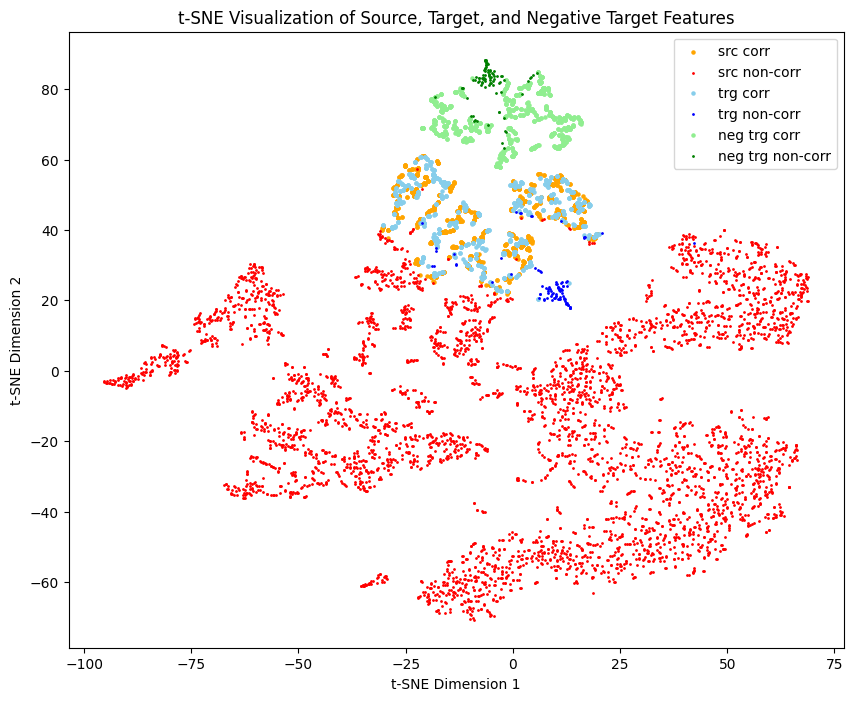

In [53]:
# 모든 특징을 하나의 행렬로 결합: src, trg, -trg
all_feats = np.concatenate((src_shape_feats, trg_shape_feats, -trg_shape_feats), axis=0)

# t-SNE 수행
tsne = TSNE(n_components=2, random_state=0)
features_2d = tsne.fit_transform(all_feats)

# 데이터 분리: src, trg, -trg의 시작 및 끝 인덱스 정의
src_end = len(src_occ_feats)
trg_start = src_end
trg_end = trg_start + len(trg_occ_feats)
neg_trg_start = trg_end
neg_trg_end = neg_trg_start + len(-trg_occ_feats)

# Correspondence 인덱스 정의
corr_src_indices = gt_correspondence[:, 0]
corr_trg_indices = gt_correspondence[:, 1] + trg_start  # trg의 인덱스를 전체 배열의 인덱스로 변환
corr_neg_trg_indices = gt_correspondence[:, 1] + neg_trg_start  # -trg의 인덱스를 변환

# Non-correspondence 인덱스
non_corr_src_indices = np.setdiff1d(np.arange(src_end), corr_src_indices)
non_corr_trg_indices = np.setdiff1d(np.arange(trg_start, trg_end), corr_trg_indices)
non_corr_neg_trg_indices = np.setdiff1d(np.arange(neg_trg_start, neg_trg_end), corr_neg_trg_indices)

# 색상 배열 생성
colors = np.array(['red'] * src_end + ['green'] * len(trg_occ_feats) + ['blue'] * len(-trg_occ_feats), dtype='object')
colors[corr_src_indices] = 'orange'
colors[corr_trg_indices] = 'skyblue'
colors[corr_neg_trg_indices] = 'lightgreen'

# 그래프 그리기
plt.figure(figsize=(10, 8))

# Source
plt.scatter(features_2d[corr_src_indices, 0], features_2d[corr_src_indices, 1], c='orange', s=5, label='src corr')
plt.scatter(features_2d[non_corr_src_indices, 0], features_2d[non_corr_src_indices, 1], c='red', s=1, label='src non-corr')

# Target
plt.scatter(features_2d[corr_trg_indices, 0], features_2d[corr_trg_indices, 1], c='skyblue', s=5, label='trg corr')
plt.scatter(features_2d[non_corr_trg_indices, 0], features_2d[non_corr_trg_indices, 1], c='blue', s=1, label='trg non-corr')

# Negative Target (-trg)
plt.scatter(features_2d[corr_neg_trg_indices, 0], features_2d[corr_neg_trg_indices, 1], c='lightgreen', s=5, label='neg trg corr')
plt.scatter(features_2d[non_corr_neg_trg_indices, 0], features_2d[non_corr_neg_trg_indices, 1], c='green', s=1, label='neg trg non-corr')

# 레이블과 타이틀 설정
plt.legend()
plt.title('t-SNE Visualization of Source, Target, and Negative Target Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()